In [36]:
import pandas as pd
import numpy as np


In [37]:
data = pd.read_csv("C:/Users/Sneha Gupta/Downloads/Fraud (1).csv")
data

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [38]:
data.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

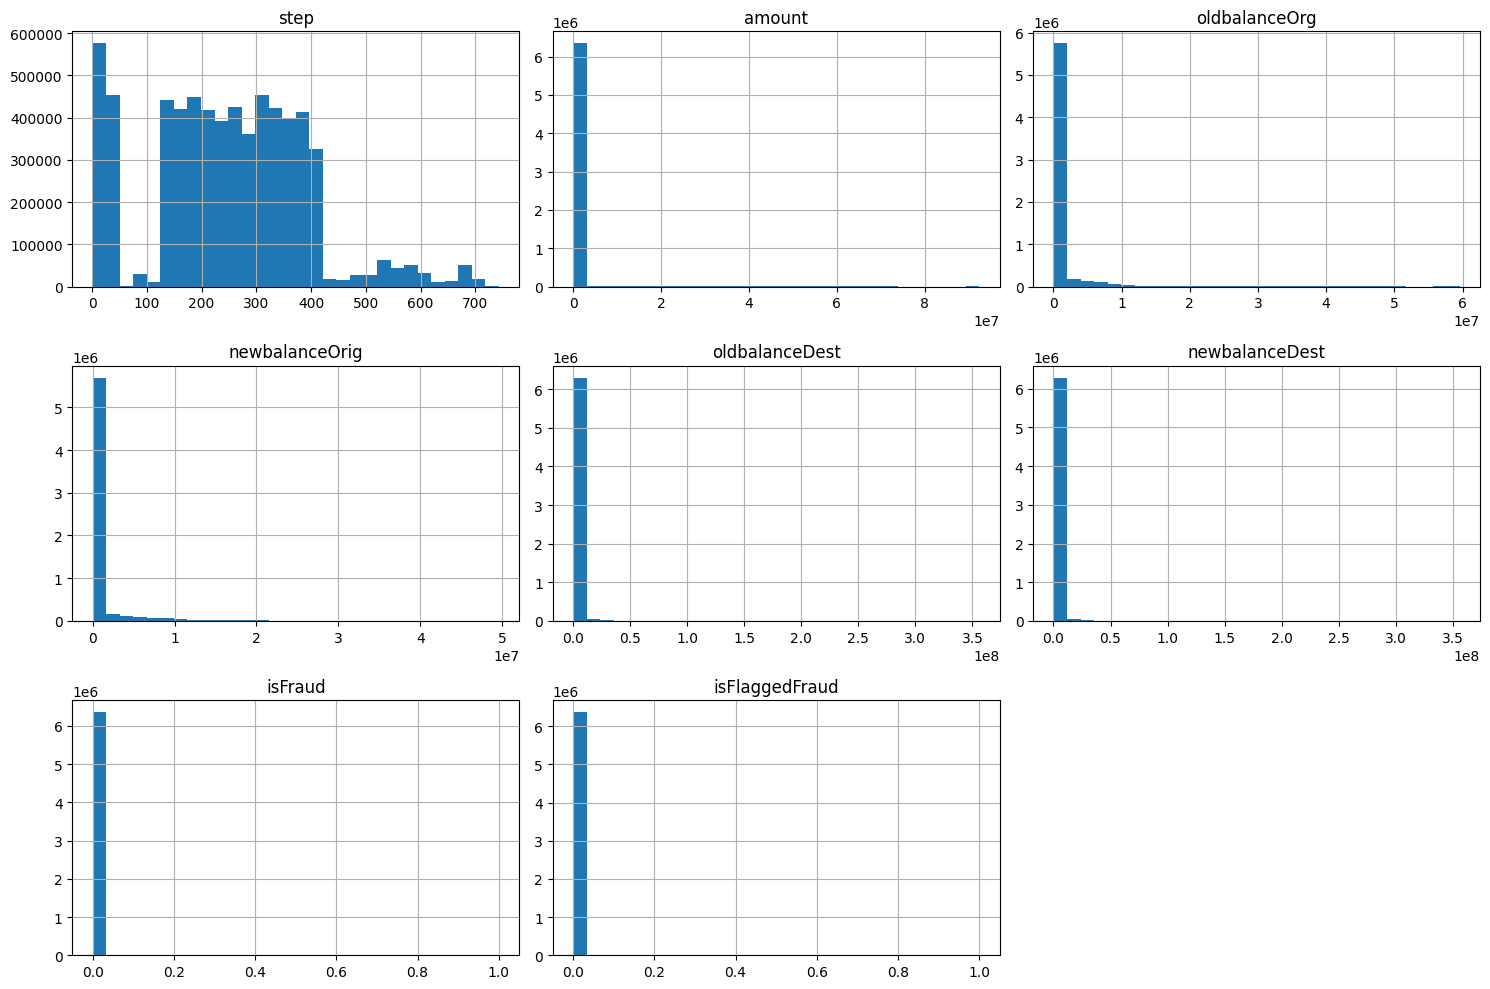

In [55]:
import matplotlib.pyplot as plt

data.hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

In [39]:
data.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [40]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder 

In [41]:
le = LabelEncoder()

In [42]:
x = data.drop(columns=['isFraud','nameOrig','nameDest'])
y = data['isFraud']

In [43]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2,random_state = 42, stratify = y)

In [44]:
x_train['type'] = le.fit_transform(x_train['type'])
x_test['type'] = le.transform(x_test['type'])

In [45]:
model = LogisticRegression(max_iter = 1000, class_weight ='balanced')

In [46]:
x_train.dtypes

step                int64
type                int64
amount            float64
oldbalanceOrg     float64
newbalanceOrig    float64
oldbalanceDest    float64
newbalanceDest    float64
isFlaggedFraud      int64
dtype: object

In [47]:
model.fit(x_train,y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [48]:
y_pred_pro = model.predict_proba(x_test)[:,1]

In [49]:
y_pred_pro

array([1.56096639e-04, 8.05932821e-03, 4.61293345e-01, ...,
       1.77323211e-02, 2.53189368e-02, 2.90159240e-02])

In [99]:
threshold = 0.1
y_pred = (y_pred_pro >= threshold).astype(int)

In [101]:
print(classification_report(y_test,y_pred),accuracy_score(y_test,y_pred))

              precision    recall  f1-score   support

           0       1.00      0.52      0.69   1270881
           1       0.00      0.99      0.01      1643

    accuracy                           0.52   1272524
   macro avg       0.50      0.76      0.35   1272524
weighted avg       1.00      0.52      0.69   1272524
 0.5239846164001623


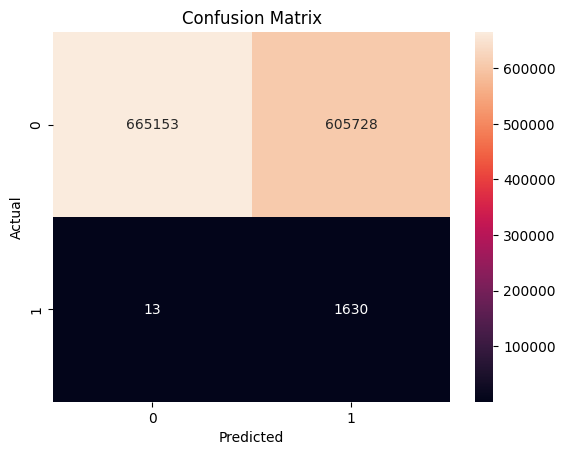

In [102]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [52]:
print(data['isFraud'].value_counts())

isFraud
0    6354407
1       8213
Name: count, dtype: int64


In [53]:
'isFraud' in x.columns

False

In [64]:
y_pred[2]

np.int64(1)

In [63]:
data['isFraud'][2]

np.int64(1)

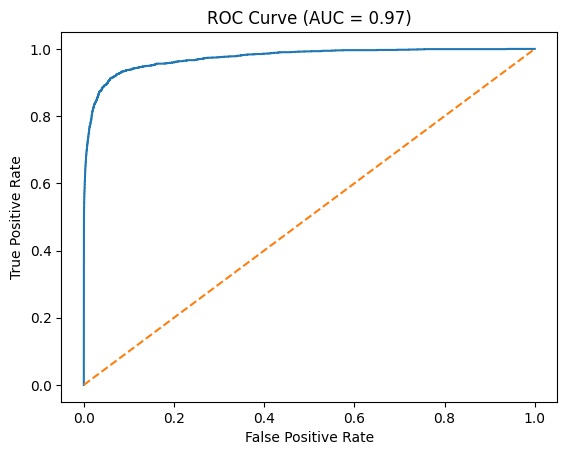

In [103]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt


fpr, tpr, _ = roc_curve(y_test, y_pred_pro)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {roc_auc:.2f})")
plt.show()
